In [5]:
import matplotlib.pyplot as plt
from sklearn import linear_model, neighbors
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [6]:
diabetes = datasets.load_diabetes()

In [7]:
def regression_residuals(ax, predicted, actual,
  show_errors=None, right=False):
  df = pd.DataFrame({'actual':actual, 'predicted':predicted})
  df['error'] = df.actual - df.predicted
  ax.plot(df.predicted, df.error, '.')
  ax.plot(df.predicted, np.zeros_like(predicted), '-')
  if right:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
  ax.set_xlabel('Predicted Value')
  ax.set_ylabel('Residual')
  if show_errors == 'all':
    show_errors = range(len(df))
  if show_errors:
    preds = df.predicted.iloc[show_errors]
    errors = df.error.iloc[show_errors]
    ax.vlines(preds, 0, errors, 'r')

Text(0.5, 1.0, 'KNN Residuals')

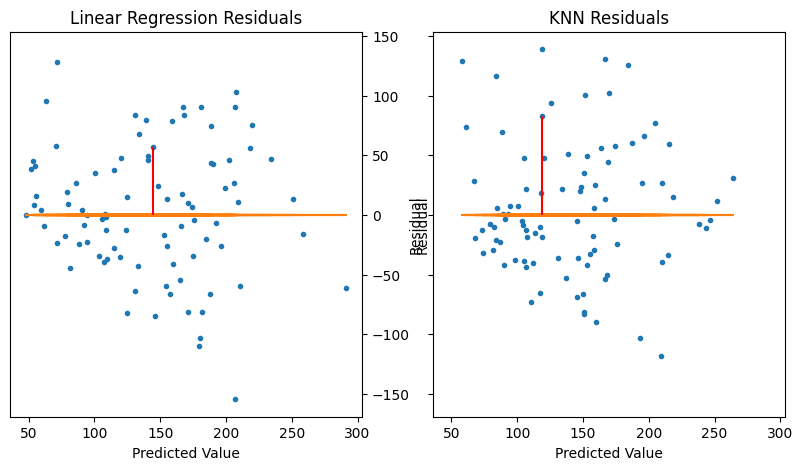

In [9]:
lr = linear_model.LinearRegression()
knn = neighbors.KNeighborsRegressor()
models = [lr, knn]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for model, ax, on_right in zip(models, axes, [True, False]):
    train_data, test_data, train_target, test_target = train_test_split(diabetes.data,diabetes.target,test_size=0.2, random_state=42)
    model.fit(train_data, train_target)
    predictions = model.predict(test_data)
    regression_residuals(ax, predictions, test_target, [-20], right=on_right)

axes[0].set_title('Linear Regression Residuals')
axes[1].set_title('KNN Residuals')